<a href="https://colab.research.google.com/github/kinantirizky/Analisis-Deret-Waktu-/blob/main/smote_mknn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import xarray as xr
import glob
from datetime import datetime
import datetime
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sn

from scipy.spatial import distance
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
main_path = 'D:\\dataset\\data_akhir\\final3' # Disesuaikan direktori anda
second_path = 'D:\\dataset\\masuk_draft\\final_new' # Disesuaikan direktori anda

In [ ]:
ds = pd.read_csv(os.path.join(main_path,'hotspot_all_labeled.csv'))
ds = ds.rename(columns={
    'TLML':'suhu',
    'PRECTOT':'curah_hujan',
    'SPEED':'kecepatan_angin',
    'QLML':'kelembapan',
    'confidence':'titik_panas'
})

In [ ]:
ds

,suhu,curah_hujan,kecepatan_angin,kelembapan,titik_panas
0,25.900934,9.014851,1.770190,18.699183,1
1,26.006729,6.916961,1.180742,18.764351,1
2,26.006729,6.916961,1.180742,18.764351,1
3,26.703360,9.718589,1.721150,19.404974,0
4,26.818945,11.827469,1.783390,18.478146,1
...,...,...,...,...,...
5795,24.954103,0.469429,2.600878,16.897049,1
5796,26.500654,0.708744,7.243589,16.975250,1
5797,26.500654,0.708744,7.243589,16.975250,1
5798,25.466475,1.728415,3.821592,17.432379,1


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5800 entries, 0 to 5799
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   suhu             5800 non-null   float64
 1   curah_hujan      5800 non-null   float64
 2   kecepatan_angin  5800 non-null   float64
 3   kelembapan       5800 non-null   float64
 4   titik_panas      5800 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 226.7 KB


In [ ]:
ds.describe()

,suhu,curah_hujan,kecepatan_angin,kelembapan,titik_panas
count,5800.000000,5800.000000,5800.000000,5800.000000,5800.000000
mean,26.436547,11.319322,1.897099,18.307127,1.154828
std,0.741882,23.497569,0.653134,0.732839,0.480875
min,22.467651,0.013114,0.563118,15.041249,0.000000
25%,25.980902,2.209191,1.507713,17.931547,1.000000
50%,26.517313,4.515566,1.769948,18.363619,1.000000
75%,26.945963,8.049551,2.191776,18.810320,1.000000
max,28.452003,229.696548,7.243589,20.951841,2.000000


In [ ]:
# statistik deskriptif data titik panas 2020-2022 kelas 0
#ds[ds['titik_panas']==0].describe().to_csv(os.path.join(second_path,'stat_deskriptif_20_22_class0.csv'))
ds[ds['titik_panas']==0].describe()

,suhu,curah_hujan,kecepatan_angin,kelembapan,titik_panas
count,291.000000,291.000000,291.000000,291.000000,291.0
mean,26.440598,10.016083,1.940184,18.356943,0.0
std,0.720707,17.944608,0.684949,0.727834,0.0
min,24.327337,0.014013,0.714864,15.509814,0.0
25%,25.973492,2.804660,1.525245,18.022453,0.0
50%,26.539816,5.125366,1.828889,18.426920,0.0
75%,26.935074,8.546966,2.231486,18.845009,0.0
max,28.446320,127.611482,4.836099,20.150711,0.0


In [ ]:
# statistik deskriptif data titik panas 2020-2022 kelas 1
#ds[ds['titik_panas']==1].describe().to_csv(os.path.join(second_path,'stat_deskriptif_20_22_class1.csv'))
ds[ds['titik_panas']==1].describe()

,suhu,curah_hujan,kecepatan_angin,kelembapan,titik_panas
count,4320.000000,4320.000000,4320.000000,4320.000000,4320.0
mean,26.429890,11.617272,1.890793,18.330263,1.0
std,0.748265,23.819821,0.642196,0.712102,0.0
min,22.467651,0.013114,0.563118,15.041249,1.0
25%,25.993771,2.399497,1.507792,17.960591,1.0
50%,26.511292,4.687308,1.767701,18.367510,1.0
75%,26.935074,8.298201,2.178493,18.814001,1.0
max,28.452003,229.696548,7.243589,20.951841,1.0


In [ ]:
# statistik deskriptif data titik panas 2020-2022 kelas 2
#ds[ds['titik_panas']==2].describe().to_csv(os.path.join(second_path,'stat_deskriptif_20_22_class2.csv'))
ds[ds['titik_panas']==2].describe()

,suhu,curah_hujan,kecepatan_angin,kelembapan,titik_panas
count,1189.000000,1189.000000,1189.000000,1189.000000,1189.0
mean,26.459744,10.555736,1.909465,18.210874,2.0
std,0.723600,23.504974,0.683861,0.798028,0.0
min,23.329779,0.013114,0.563118,15.203683,2.0
25%,25.969870,2.008177,1.491809,17.795124,2.0
50%,26.545334,3.908716,1.767701,18.293840,2.0
75%,26.984087,7.327559,2.223899,18.761215,2.0
max,28.365057,169.643858,4.995700,19.796730,2.0


In [ ]:
# split dataset to data training & data testing
# pembagian data latih dan uji dgn rasio 70:30
x_train,x_test,y_train,y_test = train_test_split(ds.iloc[:,:-1],ds.iloc[:,-1],test_size=0.3,random_state=42,stratify=ds.titik_panas)

In [ ]:
x_train

,suhu,curah_hujan,kecepatan_angin,kelembapan
1773,26.946533,7.729751,1.282288,17.930651
2190,25.372101,3.470581,1.550317,18.259779
1366,26.062647,18.092251,2.303139,19.408804
4838,25.975189,3.537847,1.507009,18.631861
1309,27.007574,4.801292,1.471757,18.829035
...,...,...,...,...
2729,25.587021,4.692900,2.046187,18.064096
501,25.071121,6.869674,1.389626,17.639671
3644,26.935074,6.979416,1.970482,18.845009
2256,26.364889,2.739796,1.436669,18.455976


In [ ]:
x_test

,suhu,curah_hujan,kecepatan_angin,kelembapan
1503,25.632492,5.870629,3.291577,17.250399
4307,26.538071,2.578890,1.485533,18.548824
2268,26.757593,3.241879,3.503011,18.654457
5030,23.714354,0.603243,2.020565,16.692345
5703,25.826899,18.487930,1.732214,18.782454
...,...,...,...,...
4358,25.728937,16.521651,1.552987,17.960503
2922,26.749712,79.319071,1.655818,18.228411
388,26.708719,3.059086,1.603881,18.872179
4493,26.748047,6.225447,1.184133,19.321859


In [ ]:
# menyimpan data latih dan data uji
##pd.concat([x_train,y_train],axis=1).to_csv(os.path.join(second_path,'train.csv'),index=False)
##pd.concat([x_test,y_test],axis=1).to_csv(os.path.join(second_path,'test.csv'),index=False)

In [ ]:
Counter(y_train)

Counter({2: 832, 1: 3024, 0: 204})

In [ ]:
Counter(y_test)

Counter({1: 1296, 2: 357, 0: 87})

# Normalisasi data

In [ ]:
# memanggil data latih dan data uji
train = pd.read_csv(os.path.join(second_path,'train.csv'))
test = pd.read_csv(os.path.join(second_path,'test.csv'))
x_train, y_train = train.iloc[:,:-1], train.iloc[:,-1].values
x_test, y_test = test.iloc[:,:-1], test.iloc[:,-1].values

In [ ]:
# min max scaler
scaler = MinMaxScaler(feature_range=(0,1))
x_train_scaled = scaler.fit_transform(x_train.to_numpy())
x_test_scaled = scaler.transform(x_test.to_numpy())

In [ ]:
x_train_scaled

array([[0.71927166, 0.03359684, 0.10765257, 0.48885144],
       [0.42568382, 0.01505318, 0.14777385, 0.54453592],
       [0.55445145, 0.07871328, 0.26046386, 0.73893691],
       ...,
       [0.71713481, 0.03033002, 0.21066835, 0.64354967],
       [0.61081122, 0.01187148, 0.13076198, 0.57773014],
       [0.58350628, 0.01640365, 0.23526387, 0.46455954]])

In [ ]:
x_test_scaled

array([[0.47423954, 0.02550256, 0.40842309, 0.37376109],
       [0.64310476, 0.01117092, 0.13807631, 0.59343886],
       [0.6840396 , 0.01405745, 0.4400727 , 0.61131064],
       ...,
       [0.67492598, 0.01326161, 0.15579184, 0.64814653],
       [0.68225948, 0.02704737, 0.09295981, 0.72422695],
       [0.30428313, 0.06704174, 0.19576874, 0.49480687]])

In [ ]:
# menyimpan data latih dan data uji yang telah di normalisasi
##pd.concat([pd.DataFrame(x_train_scaled),pd.DataFrame(y_train)],axis=1).to_csv(os.path.join(second_path,'train_scaled.csv'),index=False)
##pd.concat([pd.DataFrame(x_test_scaled),pd.DataFrame(y_test)],axis=1).to_csv(os.path.join(second_path,'test_scaled.csv'),index=False)

# MKNN w/ SMOTE

## SMOTE

In [ ]:
# memanggil data latih dan data uji yang telah di normalisasi
train_scaled = pd.read_csv(os.path.join(second_path,'train_scaled.csv'))
test_scaled = pd.read_csv(os.path.join(second_path,'test_scaled.csv'))

x_train_scaled, y_train = train_scaled.iloc[:,:-1].values, train_scaled.iloc[:,-1].values
x_test_scaled, y_test = test_scaled.iloc[:,:-1].values, test_scaled.iloc[:,-1].values

In [ ]:
Counter(y_test)

Counter({1: 1296, 2: 357, 0: 87})

In [ ]:
# Penerapan algoritma SMOTE untuk data latih
sm = SMOTE(random_state=None)
x_res_sm, y_res_sm = sm.fit_resample(x_train_scaled,y_train)

In [ ]:
# menyimpan data latih yang telah di resampling dengan SMOTE
##pd.concat([pd.DataFrame(x_res_sm),pd.DataFrame(y_res_sm)],axis=1).to_csv(os.path.join(second_path,'train_sm.csv'),index=False)

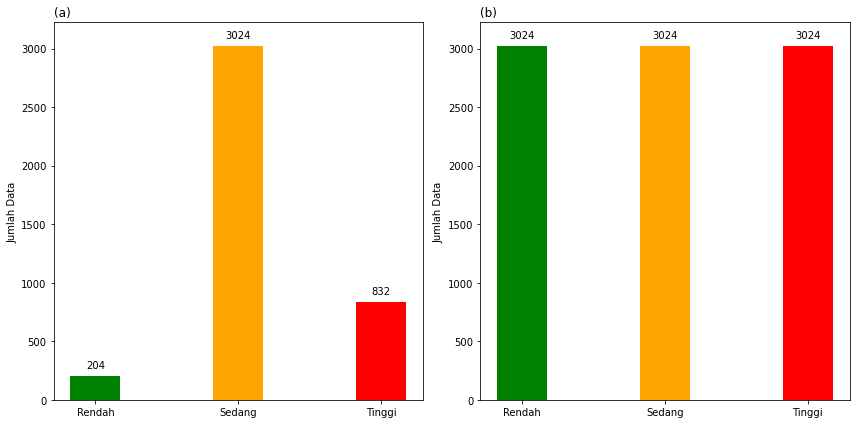

In [ ]:
# Data kelas awal dan setelah penerapan SMOTE
kelas = ['Rendah', 'Sedang', 'Tinggi']
jumlah_kelas_awal = [Counter(y_train)[0], Counter(y_train)[1], Counter(y_train)[2]]
jumlah_kelas_setelah_smote = [Counter(y_res_sm)[0], Counter(y_res_sm)[1], Counter(y_res_sm)[2]]

# Menentukan lebar bar yang lebih kecil
lebar_bar = 0.35  # Ubah lebar bar sesuai keinginan Anda
indeks = np.arange(len(kelas))

# Warna untuk setiap kelas
warna_kelas = ['green', 'orange', 'red']

# Membuat dua subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Membuat grafik pertama (Sebelum SMOTE)
bar1 = ax1.bar(indeks, jumlah_kelas_awal, width=lebar_bar, color=warna_kelas)
ax1.set_ylabel('Jumlah Data')
ax1.set_title('(a)', loc='left')
ax1.set_xticks(indeks)
ax1.set_xticklabels(kelas)
for i, j in zip(indeks, jumlah_kelas_awal):
    ax1.text(i, j + 50, str(j), ha='center', va='bottom')

# Membuat grafik kedua (Setelah SMOTE)
bar2 = ax2.bar(indeks, jumlah_kelas_setelah_smote, width=lebar_bar, color=warna_kelas)
ax2.set_ylabel('Jumlah Data')
ax2.set_title('(b)', loc='left')
ax2.set_xticks(indeks)
ax2.set_xticklabels(kelas)
for i, j in zip(indeks, jumlah_kelas_setelah_smote):
    ax2.text(i, j + 50, str(j), ha='center', va='bottom')

# Mengatur batas atas grafik agar teks tidak melewati
for ax in [ax1, ax2]:
    ax.set_ylim(0, max(max(jumlah_kelas_awal), max(jumlah_kelas_setelah_smote)) + 200)

plt.tight_layout()  # Untuk menghindari tumpang tindih antara subplot
plt.show()

In [ ]:
# statistik deskriptif data latih setelah SMOTE
# kelas rendah
train_sm[train_sm['titik_panas']==0].describe().iloc[:,:-1]

,suhu,curah_hujan,kecepatan_angin,kelembapan
count,3024.000000,3024.000000,3024.000000,3024.000000
mean,0.622111,0.040609,0.210478,0.563656
std,0.125400,0.069935,0.096582,0.113869
min,0.230864,0.000007,0.022715,0.079275
25%,0.540296,0.012547,0.150980,0.513043
50%,0.651797,0.023101,0.197496,0.573961
75%,0.717135,0.035637,0.249030,0.643550
max,0.962709,0.555540,0.639623,0.864459


In [ ]:
# statistik deskriptif data latih setelah SMOTE
# kelas sedang
train_sm[train_sm['titik_panas']==1].describe().iloc[:,:-1]

,suhu,curah_hujan,kecepatan_angin,kelembapan
count,3024.000000,3024.000000,3024.000000,3024.000000
mean,0.622193,0.049633,0.198256,0.556930
std,0.139112,0.099423,0.096474,0.120354
min,0.000000,0.000000,0.000000,0.000000
25%,0.538193,0.010513,0.141361,0.493331
50%,0.638111,0.020608,0.179962,0.562763
75%,0.717135,0.036698,0.242435,0.640298
max,1.000000,1.000000,1.000000,1.000000


In [ ]:
# statistik deskriptif data latih setelah SMOTE
# kelas tinggi
train_sm[train_sm['titik_panas']==2].describe().iloc[:,:-1]

,suhu,curah_hujan,kecepatan_angin,kelembapan
count,3024.000000,3024.000000,3024.000000,3024.000000
mean,0.624581,0.046703,0.203439,0.531034
std,0.131831,0.103582,0.102322,0.134610
min,0.044848,0.000000,0.000000,0.027482
25%,0.532035,0.008686,0.141291,0.462926
50%,0.644968,0.016900,0.177679,0.549387
75%,0.726274,0.031846,0.251115,0.627298
max,0.983787,0.738541,0.663513,0.801729


## MKNN

In [ ]:
# memanggil data latih hasil SMOTE
train_sm = pd.read_csv(os.path.join(second_path,'train_sm.csv'))
x_res_sm, y_res_sm = train_sm.iloc[:,:-1].values, train_sm.iloc[:,-1].values

In [ ]:
# jarak euclidean data latih
euc_train = euclidean_distances(x_res_sm,x_res_sm)
df_euc_train = pd.DataFrame(euc_train)
np.fill_diagonal(df_euc_train.values, np.nan)
df_euc_train['class'] = y_res_sm

# jarak euclidean data uji dan data latih
euc_test = euclidean_distances(x_test_scaled,x_res_sm)
df_euc_test = pd.DataFrame(euc_test)
df_euc_test['class'] = y_test

In [ ]:
#df_euc_train.to_csv(os.path.join(second_path,'train_euc.csv'),index=False)
df_euc_train

,0,1,2,3,4,5,6,7,8,9,...,9063,9064,9065,9066,9067,9068,9069,9070,9071,class
0,NaN,0.302073,0.339257,0.219879,0.155561,0.293407,0.414544,0.354294,0.230005,0.259558,...,0.068898,0.365759,0.151594,0.345804,0.278785,0.278812,0.124100,0.378177,0.139266,2
1,0.302073,NaN,0.266692,0.129043,0.320085,0.307995,0.496047,0.353657,0.413196,0.218848,...,0.301113,0.489232,0.346638,0.198502,0.200777,0.200645,0.210789,0.254923,0.361031,2
2,0.339257,0.266692,NaN,0.189110,0.243937,0.287324,0.271959,0.180866,0.415315,0.114730,...,0.286613,0.414066,0.267076,0.333237,0.133463,0.133539,0.245996,0.432943,0.300884,1
3,0.219879,0.129043,0.189110,NaN,0.195529,0.278229,0.376900,0.285814,0.358949,0.134654,...,0.198139,0.426280,0.232719,0.258642,0.098394,0.098337,0.103995,0.330882,0.258269,1
4,0.155561,0.320085,0.243937,0.195529,NaN,0.307739,0.263139,0.283113,0.301619,0.195067,...,0.094287,0.374155,0.079932,0.391678,0.195652,0.195779,0.123929,0.458254,0.125678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9067,0.278785,0.200777,0.133463,0.098394,0.195652,0.327969,0.309462,0.277265,0.418820,0.140275,...,0.239087,0.430515,0.248078,0.333705,NaN,0.000257,0.160202,0.417681,0.287389,2
9068,0.278812,0.200645,0.133539,0.098337,0.195779,0.328053,0.309660,0.277412,0.418911,0.140400,...,0.239158,0.430439,0.248221,0.333677,0.000257,NaN,0.160217,0.417630,0.287513,2
9069,0.124100,0.210789,0.245996,0.103995,0.123929,0.286054,0.364194,0.309536,0.304367,0.177246,...,0.106555,0.391545,0.162601,0.307203,0.160202,0.160217,NaN,0.363171,0.184193,2
9070,0.378177,0.254923,0.432943,0.330882,0.458254,0.266866,0.649217,0.413311,0.355171,0.349287,...,0.396420,0.567059,0.439865,0.107878,0.417681,0.417630,0.363171,NaN,0.423657,2


In [ ]:
#df_euc_test.to_csv(os.path.join(second_path,'test_train_euc.csv'),index=False)
df_euc_test

,0,1,2,3,4,5,6,7,8,9,...,9063,9064,9065,9066,9067,9068,9069,9070,9071,class
0,0.404741,0.315545,0.405599,0.360797,0.459686,0.190457,0.610842,0.338280,0.319729,0.326403,...,0.405258,0.552812,0.425404,0.119624,0.431044,0.431041,0.393477,0.135946,0.406042,1
1,0.134790,0.223097,0.220386,0.106029,0.100051,0.264853,0.331916,0.275340,0.291809,0.148136,...,0.097329,0.390038,0.134607,0.305638,0.148771,0.148838,0.038376,0.369985,0.161525,1
2,0.356542,0.395786,0.263669,0.332525,0.309100,0.145396,0.342775,0.088915,0.265897,0.207204,...,0.307299,0.476503,0.256697,0.320624,0.342245,0.342398,0.338554,0.406842,0.253139,1
3,0.648329,0.413515,0.640750,0.539891,0.717550,0.570758,0.894207,0.676889,0.677204,0.594133,...,0.670973,0.791792,0.723641,0.378346,0.609719,0.609584,0.602616,0.324416,0.719199,1
4,0.266624,0.141522,0.143070,0.082383,0.231527,0.279350,0.375203,0.264404,0.386167,0.129523,...,0.239255,0.390709,0.265251,0.259329,0.100402,0.100261,0.163650,0.340706,0.289806,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,0.233845,0.101095,0.276713,0.135104,0.284945,0.272176,0.491125,0.341593,0.346740,0.216505,...,0.243493,0.409208,0.302155,0.192182,0.221537,0.221409,0.174351,0.234432,0.306037,1
1736,0.322738,0.418713,0.369793,0.367251,0.344466,0.403104,0.482710,0.409774,0.405028,0.370718,...,0.317249,0.079073,0.349390,0.452127,0.382253,0.382159,0.340999,0.491577,0.342649,2
1737,0.173414,0.270045,0.194929,0.143448,0.060063,0.279515,0.266442,0.250467,0.310123,0.141556,...,0.115165,0.388425,0.108613,0.348106,0.142429,0.142571,0.099078,0.421932,0.152233,2
1738,0.238810,0.318227,0.217436,0.192017,0.105766,0.375085,0.236186,0.316228,0.402590,0.212442,...,0.188868,0.401808,0.180824,0.432002,0.146065,0.146182,0.160408,0.506659,0.229693,1


### Validity data training

In [ ]:
# memanggil dataset jarak euclidean data latih
df_euc_train = pd.read_csv(os.path.join(second_path,'train_euc.csv'))

# memanggil dataset jarak euclidean data uji dan data latih
df_euc_test = pd.read_csv(os.path.join(second_path,'test_train_euc.csv'))

In [ ]:
# validitas data latih
validity = []
validity_dict = {}
ds_validasi = pd.DataFrame({'kelas_data':y_res_sm})
ds_validasi2 = pd.DataFrame({'kelas_data':y_res_sm})
k = 4

# membuat dictionary berisi data jarak,kelas,indeks,kolom tiap k
for i in range(k):
    jarak = []
    kelas = []
    indeks = []
    kolom = []

    for j in range(len(df_euc_train.columns)-1):
        df = df_euc_train.iloc[:,[j,-1]]

        df_melted = df.melt(
        id_vars = ['class'],
        var_name = 'kolom',
        value_name = 'jarak',
        ignore_index=False)

        df_melted = df_melted.reset_index(drop=False)

        df_melted = df_melted.dropna()

        dt = df_melted.sort_values('jarak').reset_index(drop=True)

        a = dt['jarak'][i]
        b = dt['class'][i]
        c = dt['kolom'][i]
        d = dt['index'][i]

        jarak.append(a)
        kelas.append(b)
        indeks.append(d)
        kolom.append(c)

    validity_dict[i+1] = {
        'kolom': kolom,
        'indeks': indeks,
        'jarak': jarak,
        'kelas': kelas
    }

# membuat dataframe ds_validasi untuk membandingkan kelas asli
# dengan kelas terdekat
for i in range(k):
    kelas = validity_dict[i+1]['kelas']
    ds_validasi[i+1] = kelas

# konversi kelas terdekat sebanyak k
# dengan aturan jika kelas k = kelas asli maka kategori 1
# jika kelas k != kelas asli maka kategori 0
for i in range(k):
    K = []

    for j in range(len(ds_validasi)):
        if ds_validasi.loc[j,i+1] == ds_validasi.loc[j,'kelas_data']:
            K.append(1)
        else:
            K.append(0)

    ds_validasi2[i+1] = K

# menghitung nilai validitas data latih
for i in range(len(ds_validasi2)):
    sum_similarity = ds_validasi2.iloc[i,1:].sum(axis=0)
    val = (1/k)*(sum_similarity)
    validity.append(val)

In [ ]:
# menyimpan hasil perhitungan validitas data latih
#ds_validasi2.to_csv(os.path.join(second_path,'data_similarity.csv'),index=False)
#pd.DataFrame(validity).to_csv(os.path.join(second_path,'train_validity.csv'),index=False)

In [ ]:
# memanggil hasil validitas data latih
validity = pd.read_csv(os.path.join(second_path,'train_validity.csv'))
validity = validity.to_numpy()

In [ ]:
validity

array([[0.5 ],
       [0.5 ],
       [0.25],
       ...,
       [0.75],
       [1.  ],
       [1.  ]])

### Weight Voting

In [ ]:
df_euc_test_melted = df_euc_test.melt(
        id_vars = ['class'],
        var_name = 'kolom',
        value_name = 'jarak',
        ignore_index=False).reset_index(drop=False)

In [ ]:
W = []

for i in df_euc_test_melted['index'].unique():
    df = df_euc_test_melted[df_euc_test_melted['index']==i].reset_index(drop=True)

    for j in range(len(validity)):
        w = 1/(df['jarak'][j]+0.5)
        w *= validity[j]

        W.append(w)

In [ ]:
df_wv = pd.DataFrame(np.array(W).reshape(-1,len(validity))).transpose()
#df_wv.to_csv(os.path.join(second_path,'data_wvk4.csv'),index=False) ## menyimpan hasil weight voting
df_wv

,0,1,2,3,4,5,6,7,8,9,...,1730,1731,1732,1733,1734,1735,1736,1737,1738,1739
0,0.552645,0.787662,0.583742,0.435415,0.652210,0.671846,0.662617,0.823467,0.761806,0.701348,...,0.511774,0.607666,0.723656,0.753946,0.756164,0.681343,0.607727,0.742485,0.676764,0.540191
1,0.613087,0.691470,0.558169,0.547337,0.779397,0.645227,0.550405,0.684347,0.620855,0.722179,...,0.704505,0.495347,0.769828,0.538243,0.537738,0.831815,0.544240,0.649313,0.611077,0.770351
2,0.276060,0.347036,0.327367,0.219154,0.388760,0.398694,0.243998,0.304519,0.330835,0.383633,...,0.277728,0.293047,0.347543,0.284021,0.287183,0.321869,0.287425,0.359749,0.348463,0.292167
3,0.580857,0.825043,0.600583,0.480820,0.858542,0.765772,0.556679,0.726955,0.733276,0.879080,...,0.604939,0.567036,0.836567,0.612886,0.608273,0.787272,0.576534,0.777064,0.722526,0.649151
4,0.781505,1.249893,0.926956,0.615991,1.025252,1.204162,0.836407,1.045569,1.358693,1.156834,...,0.741985,1.073555,1.059283,1.172054,1.147731,0.955481,0.888135,1.339134,1.238103,0.783721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9067,0.537032,0.770687,0.593652,0.450565,0.832775,0.827457,0.507343,0.648072,0.733629,0.877509,...,0.570717,0.589265,0.735241,0.602500,0.592290,0.692966,0.566731,0.778296,0.773916,0.604822
9068,0.537034,0.770609,0.593543,0.450619,0.832971,0.827238,0.507341,0.648082,0.733535,0.877493,...,0.570834,0.589140,0.735232,0.602427,0.592206,0.693088,0.566791,0.778124,0.773776,0.604936
9069,0.839417,1.393079,0.894397,0.680201,1.130114,1.142449,0.890589,1.177603,1.236601,1.248235,...,0.828244,0.912384,1.203873,1.043243,1.024864,1.112181,0.891796,1.251924,1.135661,0.881369
9070,1.572461,1.149445,1.102727,1.212980,1.189477,1.054572,1.238030,1.294889,1.037330,1.133672,...,1.286076,0.880574,1.316096,0.969655,1.002169,1.361597,1.008494,1.084679,0.993385,1.362548


In [ ]:
k = 4
kelas_pred = []
for i in df_wv.columns:
    wv = df_wv.iloc[:,int(i)].to_numpy()
    Class = df_euc_train['class'].to_numpy()

    result_stack = np.hstack((wv,Class)).reshape(2,len(validity)).T
    result_stack = result_stack[result_stack[:,0].argsort()[::-1]]

    # hanya mengambil kelas sebanyak k = 4
    data_k = result_stack[:k]

    # mengambil kelas mayoritas pada k terdekat
    kelas_mayoritas = np.argmax(np.bincount(data_k[:,1].astype(int)))
    kelas_pred.append(kelas_mayoritas)

In [ ]:
#pd.DataFrame(kelas_pred).to_csv(os.path.join(second_path,'ypredk4.csv'),index=False)
kelas_pred

[0,
 0,
 0,
 1,
 2,
 1,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 2,
 0,
 2,
 0,
 0,
 2,
 0,
 0,
 1,
 0,
 0,
 2,
 0,
 1,
 0,
 2,
 2,
 1,
 2,
 0,
 0,
 0,
 2,
 0,
 2,
 2,
 0,
 0,
 0,
 0,
 1,
 2,
 2,
 1,
 2,
 0,
 0,
 0,
 2,
 1,
 2,
 2,
 0,
 0,
 1,
 1,
 0,
 1,
 2,
 2,
 1,
 1,
 2,
 2,
 0,
 1,
 1,
 2,
 2,
 0,
 2,
 2,
 1,
 2,
 1,
 0,
 1,
 0,
 2,
 1,
 0,
 1,
 2,
 1,
 1,
 2,
 0,
 2,
 1,
 0,
 2,
 2,
 2,
 0,
 2,
 2,
 2,
 0,
 0,
 1,
 1,
 2,
 0,
 0,
 0,
 0,
 2,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 2,
 0,
 2,
 0,
 1,
 0,
 2,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 2,
 2,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 2,
 1,
 1,
 0,
 1,
 0,
 0,
 2,
 2,
 0,
 1,
 0,
 0,
 2,
 0,
 1,
 2,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 2,
 1,
 2,
 0,
 0,
 2,
 1,
 2,
 2,
 2,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 2,
 0,
 1,
 2,
 1,
 2,
 0,
 1,
 1,
 1,
 2,
 2,
 0,
 2,
 2,
 0,
 0,
 0,
 0,
 2,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 0,
 1,
 2,
 2,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 1,
 2,
 2,
 1,
 0,
 2,
 1,
 2,
 0,
 2,
 0,
 2,
 2,


# Evaluasi Performa

In [ ]:
# memanggil kelas titik panas hasil prediksi
kelas_pred = pd.read_csv(os.path.join(second_path,'ypredk4.csv'))
kelas_pred = kelas_pred.to_numpy()

In [ ]:
y_true = y_test.astype(int)
y_pred = np.array(kelas_pred)
labels = [0,1,2]

In [ ]:
cm_smote = confusion_matrix(y_true,y_pred,labels=labels)
df_cm_smote = pd.DataFrame(cm_smote,labels,labels)

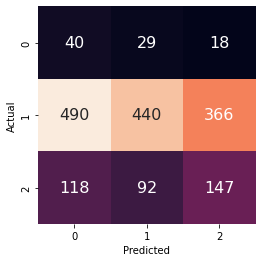

In [ ]:
# SMOTE
ax = sn.heatmap(
    df_cm_smote,
    annot=True,
    annot_kws={"size": 16},
    square=True,
    cbar=False,
    fmt='g')

ax.set_ylim(0, 3)
plt.xlabel("Predicted")
plt.ylabel("Actual")
ax.invert_yaxis()
plt.show()

In [ ]:
print('Classification Report')
print('Akurasi          :',round(accuracy_score(y_true,y_pred),2))
print('-'*36)
print('Recall (Rendah)  :',round(recall_score(y_true,y_pred,average=None)[0],2))
print('Recall (Sedang)  :',round(recall_score(y_true,y_pred,average=None)[1],2))
print('Recall (Tinggi)  :',round(recall_score(y_true,y_pred,average=None)[2],2))
print('Average Recall   :',round(recall_score(y_true,y_pred,average='macro'),2))
print('-'*36)
print('Presisi (Rendah) :',round(precision_score(y_true,y_pred,average=None)[0],2))
print('Presisi (Sedang) :',round(precision_score(y_true,y_pred,average=None)[1],2))
print('Presisi (Tinggi) :',round(precision_score(y_true,y_pred,average=None)[2],2))
print('Average Presisi  :',round(precision_score(y_true,y_pred,average='macro'),2))
print('-'*36)
print('F1-Score (Rendah):',round(f1_score(y_true,y_pred,average=None)[0],2))
print('F1-Score (Sedang):',round(f1_score(y_true,y_pred,average=None)[1],2))
print('F1-Score (Tinggi):',round(f1_score(y_true,y_pred,average=None)[2],2))
print('Average F1-Score :',round(f1_score(y_true,y_pred,average='macro'),2))

Classification Report
Akurasi          : 0.36
------------------------------------
Recall (Rendah)  : 0.46
Recall (Sedang)  : 0.34
Recall (Tinggi)  : 0.41
Average Recall   : 0.4
------------------------------------
Presisi (Rendah) : 0.06
Presisi (Sedang) : 0.78
Presisi (Tinggi) : 0.28
Average Presisi  : 0.37
------------------------------------
F1-Score (Rendah): 0.11
F1-Score (Sedang): 0.47
F1-Score (Tinggi): 0.33
Average F1-Score : 0.3
